# DeepGuard — Reinforcement Learning for Automated Cyber Defense

We train an RL **defender** on [gym-idsgame](https://github.com/Limmen/gym-idsgame), an abstract Markov-game model of intrusion prevention: an attacker tries to reach and hack a data node while the defender allocates defense and detection resources. The business context is a healthcare provider that must protect patient data: defense policies should *adapt* to attacker behavior instead of relying on static rules.

**Scenarios** (attacker is a built-in bot):
- `random_attack-v21` — the attacker picks random attacks.
- `maximal_attack-v21` — the attacker always uses its strongest attack.

**Agents & structure**:
1. Environment setup and a **random-defender baseline** (control group).
2. **Section A — SARSA** (tabular, on-policy) on the random-attack scenario.
3. **Section B — DDQN** (Double Deep Q-Network) on both scenarios.
4. **Comparative analysis** and conclusions.

> Developed on a local Miniconda env (`mlenv`). On Google Colab, first run `!pip install --no-deps gym-idsgame` and restart the runtime.

## 1. Environment Setup

`gym_idsgame` ships with a small incompatibility in recent Python/gym versions: two bot-agent modules reference `idsgame_util` without importing it. The patch below injects the module before any environment is created.

In [62]:
import gym_idsgame.envs.util.idsgame_util as _idsgame_util
import gym_idsgame.agents.bot_agents.random_attack_bot_agent as _random_bot
import gym_idsgame.agents.bot_agents.attack_maximal_value_bot_agent as _maximal_bot

if not hasattr(_random_bot, 'idsgame_util'):
    _random_bot.idsgame_util = _idsgame_util
    print("Patch applied: random_attack_bot_agent")

if not hasattr(_maximal_bot, 'idsgame_util'):
    _maximal_bot.idsgame_util = _idsgame_util
    print("Patch applied: attack_maximal_value_bot_agent")

Imports, a `set_seed()` utility for reproducibility, and the fixed colors used in all charts.

In [63]:
import random
from collections import defaultdict, deque, Counter

import numpy as np
import torch
import matplotlib.pyplot as plt


def set_seed(seed: int = 42) -> None:
    """Seed python, numpy and torch RNGs for reproducible runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


SEED = 42
set_seed(SEED)

# Fixed series colors used in every chart of this notebook
COLOR_BASELINE = "#8a8a85"   # neutral gray
COLOR_SARSA = "#2a78d6"      # blue
COLOR_DDQN = "#1baf7a"       # aqua

### Defender wrapper

gym-idsgame is a two-player Markov game: `step()` expects an `(attacker_action, defender_action)` tuple and returns paired observations/rewards. `DefenderWrapper` turns it into a standard single-agent interface for the defender — the attacker move is handled by the environment's internal bot.

In [64]:
from typing import Optional


class DefenderWrapper:
    """
    Adapts gym-idsgame to a single-agent setting from the defender's point of view.
    The attacker move is delegated to the environment's internal bot.
    """

    def __init__(self, env, seed: Optional[int] = None):
        self.env = env
        self.action_space = env.defender_action_space
        if seed is not None:
            # gym spaces have their own RNG, not covered by np.random.seed
            self.env.attacker_action_space.seed(seed)
            self.env.defender_action_space.seed(seed)

    def reset(self) -> np.ndarray:
        """Reset the environment and return the flattened defender observation."""
        obs = self.env.reset()
        # reset() returns (attacker_obs, defender_obs)
        if isinstance(obs, tuple):
            obs = obs[1]
        return obs.flatten()

    def step(self, action: int):
        """Apply the defender action and return (obs, reward, done, info) for the defender."""
        # Pass a random action (!= -1) to activate the attacking bot
        attacker_action = self.env.attacker_action_space.sample()
        res = self.env.step((attacker_action, action))

        obs, reward, done = res[0], res[1], res[2]
        info = res[3] if len(res) > 3 else {}

        # Expose the true game outcome (see Section 2: reward alone is ambiguous)
        info["hacked"] = self.env.state.hacked
        info["detected"] = self.env.state.detected

        # Extract the defender's observation and reward
        if isinstance(obs, tuple):
            obs = obs[1]
        if isinstance(reward, tuple):
            reward = reward[1]

        return obs.flatten(), reward, done, info

### Smoke tests

A few random steps in both scenarios to verify the wrapper: observations are flat 20-dim vectors and the defender has 20 discrete actions.

In [65]:
from gym_idsgame.envs import IdsGameRandomAttackV21Env, IdsGameMaximalAttackV21Env

# --- Random Attack ---
raw_env = IdsGameRandomAttackV21Env()
env = DefenderWrapper(raw_env)

obs = env.reset()
print(f"Initial observation: shape={obs.shape}, dtype={obs.dtype}")
print(f"Number of defender's actions: {env.action_space.n}")

# Take 5 random steps
for i in range(5):
    action = env.action_space.sample()
    obs, reward, done, info = env.step(action)
    print(f"  Step {i+1}: reward={reward}, done={done}, obs_shape={obs.shape}")
    if done:
        break

print("\nRandom Attack: OK!")

Initial observation: shape=(20,), dtype=float64
Number of defender's actions: 20
  Step 1: reward=0, done=False, obs_shape=(20,)
  Step 2: reward=0, done=True, obs_shape=(20,)

Random Attack: OK!


In [66]:
# --- Maximal Attack ---
raw_env_max = IdsGameMaximalAttackV21Env()
env_max = DefenderWrapper(raw_env_max)

obs = env_max.reset()
print(f"Initial observation: shape={obs.shape}, dtype={obs.dtype}")
print(f"Number of defender's actions: {env_max.action_space.n}")

for i in range(5):
    action = env_max.action_space.sample()
    obs, reward, done, info = env_max.step(action)
    print(f"  Step {i+1}: reward={reward}, done={done}")
    if done:
        break

print("\nMaximal Attack: OK!")

Initial observation: shape=(20,), dtype=float64
Number of defender's actions: 20
  Step 1: reward=0, done=True

Maximal Attack: OK!


## 2. Game Mechanics & Random Baseline (Control Group)

Reading the environment source clarifies how the game actually works (v21, `dense_rewards_v3`):

- The network has 4 nodes: **start** → 2 **servers** → **data**. The attacker invests in attack types; an attack on a node succeeds if its `attack_value > defense_value` for that type.
- **Detection is only rolled when an attack fails**, with probability `detection_value / 10` of the attacked node.
- Every episode therefore ends in one of two ways: the data node is **hacked** (defender reward ≈ −26) or the attacker is **detected**. On detection the defender's reward equals *how much it raised the data node's minimum defense* since the start — a detection without hardening pays **0**.

So a cumulative reward of 0 is not a stalemate: it is a detection with no hardening bonus. We track the real outcome (`hacked` / `detected`) alongside the reward-based classification.

**Evaluation protocol** for every agent: 500 episodes, max 100 steps, reporting positive-reward rate, breach rate, detection rate, and average reward.

In [47]:
from typing import Callable, Dict


def evaluate_policy(env: DefenderWrapper, select_action: Callable[[np.ndarray], int],
                    n_episodes: int = 500, max_steps: int = 100) -> Dict[str, float]:
    """
    Run `n_episodes` with the given policy and return reward statistics plus the
    true game outcomes (breach vs detection). Single evaluation protocol shared
    by the baseline, SARSA and DDQN, so all results are directly comparable.
    """
    wins, hacked, detected = 0, 0, 0
    total_rewards = []

    for _ in range(n_episodes):
        obs = env.reset()
        done, ep_reward, steps = False, 0, 0
        info = {}
        while not done and steps < max_steps:
            obs, reward, done, info = env.step(select_action(obs))
            ep_reward += reward
            steps += 1
        total_rewards.append(ep_reward)
        wins += ep_reward > 0
        hacked += info.get("hacked", False)
        detected += info.get("detected", False)

    return {
        "win_pct": wins / n_episodes * 100,
        "hacked_pct": hacked / n_episodes * 100,
        "detected_pct": detected / n_episodes * 100,
        "avg_reward": float(np.mean(total_rewards)),
        "std_reward": float(np.std(total_rewards)),
    }


def print_stats(label: str, stats: Dict[str, float]) -> None:
    """Pretty-print the metrics returned by `evaluate_policy`."""
    print(f"{label}: positive reward {stats['win_pct']:.1f}% | "
          f"breached {stats['hacked_pct']:.1f}% | detected {stats['detected_pct']:.1f}% | "
          f"avg reward {stats['avg_reward']:.2f} ± {stats['std_reward']:.2f}")


# Control group: uniformly random defender
results = {"random": {}, "maximal": {}}

set_seed(SEED)
env_random = DefenderWrapper(IdsGameRandomAttackV21Env(), seed=SEED)
env_maximal = DefenderWrapper(IdsGameMaximalAttackV21Env(), seed=SEED)

results["random"]["Random baseline"] = evaluate_policy(env_random, lambda o: env_random.action_space.sample())
results["maximal"]["Random baseline"] = evaluate_policy(env_maximal, lambda o: env_maximal.action_space.sample())

print_stats("Random Attack  | random defender", results["random"]["Random baseline"])
print_stats("Maximal Attack | random defender", results["maximal"]["Random baseline"])

Random Attack  | random defender: positive reward 0.0% | breached 48.8% | detected 51.2% | avg reward -12.68 ± 12.99
Maximal Attack | random defender: positive reward 0.2% | breached 64.6% | detected 35.4% | avg reward -16.79 ± 12.43


## 3. Section A — SARSA (Random Attack)

**SARSA** is *on-policy*: it learns the value of the policy it is actually executing, exploration included. In a security setting this is a desirable bias — the learned values account for the mistakes the agent still makes while exploring, favoring conservative policies over ones that look good only under perfect greedy play (what off-policy Q-learning estimates).

**State representation.** The defender observation is its own 4×5 matrix (4 nodes × 4 defense values + 1 detection value) of small integers, so tuples of integers could be used directly as Q-table keys. A first attempt with the full 20-dim state failed: ~10⁵ distinct states are visited during training, most exactly once, so nothing generalizes and the greedy policy stays at baseline level. Tabular methods need a *compact* state, and the game mechanics (Section 2) tell us which features matter: the defender's score depends on the **data node** (its 4 defenses drive the hardening bonus, its detection value drives the final detection roll). We therefore aggregate the state to the data node's 5 values, capped at 3 (episodes are too short for higher values to be reached or to matter), doing that we observed ~200 visited states instead of ~10⁵.

**Pessimistic initialization.** All rewards are ≤ 0 except the rare hardening bonuses, so a zero-initialized Q-table is *optimistic*: every unexplored action looks better than anything already tried, and the agent wastes its budget chasing unvisited entries. Initializing Q at the baseline average return (≈ −13) removes this bias.

**Hyperparameters:** α = 0.05, γ = 0.99, ε: 1.0 → 0.02 (exponential decay, floor reached halfway through training), 50 000 episodes, max 100 steps.

In [48]:
# Sanity check of the state representation and node layout
obs = env_random.reset()
print(f"Observation values are integers: {np.allclose(obs, obs.round())}")
print(f"Rows = nodes (data, server, server, start), columns = 4 defenses + detection:\n{obs.reshape(4, 5)}")

node_list = env_random.env.idsgame_config.game_config.network_config.node_list
print(f"\nNode types (3=data, 2=server, 1=start): {node_list}")

obs2, _, _, _ = env_random.step(0)
print(f"After defend-action 0, changed dims: {np.flatnonzero(obs2 - obs)} (deterministic +1 on one entry)")

Observation values are integers: True
Rows = nodes (data, server, server, start), columns = 4 defenses + detection:
[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]]

Node types (3=data, 2=server, 1=start): [np.float64(3.0), np.float64(2.0), np.float64(2.0), np.float64(1.0)]
After defend-action 0, changed dims: [0] (deterministic +1 on one entry)


In [49]:
from typing import Tuple, List

STATE_CAP = 3  # defense/detection levels above this are indistinguishable in short episodes


def state_key(obs: np.ndarray) -> Tuple[int, ...]:
    """Compact tabular state: the data node's 4 defenses + detection value, capped."""
    return tuple(np.minimum(obs[:5], STATE_CAP).astype(int))


def greedy_action(q_values: np.ndarray) -> int:
    """Argmax with random tie-breaking (plain argmax would bias ties toward action 0)."""
    best = np.flatnonzero(q_values == q_values.max())
    return int(np.random.choice(best))


def train_sarsa(env: DefenderWrapper, n_episodes: int = 50_000, alpha: float = 0.05,
                gamma: float = 0.99, eps_start: float = 1.0, eps_min: float = 0.02,
                eps_decay_fraction: float = 0.5, q_init: float = -13.0,
                max_steps: int = 100, log_every: int = 10_000):
    """
    Train a tabular SARSA defender.

    Returns the Q-table and the list of episode rewards. `q_init` pessimistically
    initializes Q-values (see rationale above). Epsilon decays exponentially,
    reaching `eps_min` after `eps_decay_fraction` of the episodes.
    """
    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.full(n_actions, q_init))

    def eps_greedy(s: Tuple[int, ...], eps: float) -> int:
        if np.random.rand() < eps:
            return np.random.randint(n_actions)
        return greedy_action(Q[s])

    eps = eps_start
    decay = np.exp(np.log(eps_min / eps_start) / (eps_decay_fraction * n_episodes))
    episode_rewards: List[float] = []

    for ep in range(n_episodes):
        s = state_key(env.reset())
        a = eps_greedy(s, eps)
        done, ep_reward, steps = False, 0, 0

        while not done and steps < max_steps:
            obs2, r, done, _ = env.step(a)
            s2 = state_key(obs2)
            a2 = eps_greedy(s2, eps)  # on-policy: the action actually taken next
            Q[s][a] += alpha * (r + gamma * Q[s2][a2] * (not done) - Q[s][a])
            s, a = s2, a2
            ep_reward += r
            steps += 1

        episode_rewards.append(ep_reward)
        eps = max(eps_min, eps * decay)
        if (ep + 1) % log_every == 0:
            print(f"  episode {ep+1:>6}: eps={eps:.3f} | "
                  f"avg reward (last 2000)={np.mean(episode_rewards[-2000:]):.2f} | "
                  f"states visited={len(Q)}")

    return Q, episode_rewards

In [50]:
%%time
set_seed(SEED)
print("Training SARSA on Random Attack...")
Q_sarsa, sarsa_rewards = train_sarsa(env_random)

Training SARSA on Random Attack...
  episode  10000: eps=0.209 | avg reward (last 2000)=-10.95 | states visited=193
  episode  20000: eps=0.044 | avg reward (last 2000)=-7.44 | states visited=205
  episode  30000: eps=0.020 | avg reward (last 2000)=-6.63 | states visited=205
  episode  40000: eps=0.020 | avg reward (last 2000)=-5.13 | states visited=205
  episode  50000: eps=0.020 | avg reward (last 2000)=-4.82 | states visited=205
CPU times: user 54.4 s, sys: 1.23 s, total: 55.6 s
Wall time: 56.3 s


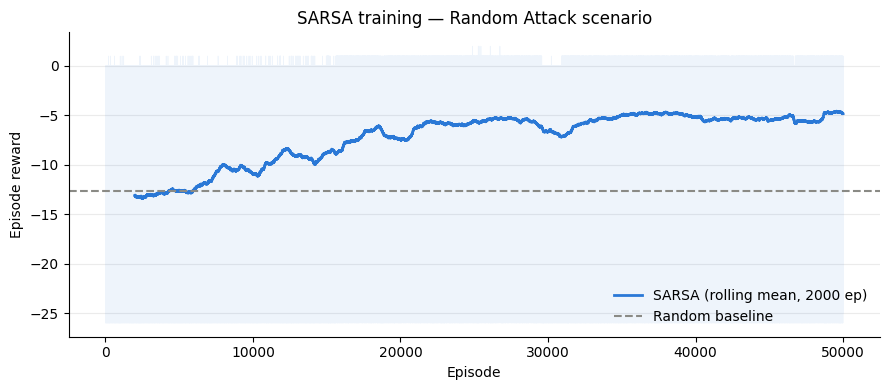

In [51]:
def rolling_mean(values: List[float], window: int) -> np.ndarray:
    """Simple moving average used for all learning-curve plots."""
    return np.convolve(values, np.ones(window) / window, mode="valid")


def plot_learning_curve(ax: plt.Axes, rewards: List[float], window: int,
                        color: str, label: str) -> None:
    """Plot raw episode rewards (faint) and their rolling mean on the given axis."""
    ax.plot(rewards, color=color, alpha=0.08, linewidth=0.5)
    ax.plot(np.arange(window - 1, len(rewards)), rolling_mean(rewards, window),
            color=color, linewidth=2, label=label)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Episode reward")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)


fig, ax = plt.subplots(figsize=(9, 4))
plot_learning_curve(ax, sarsa_rewards, window=2000, color=COLOR_SARSA, label="SARSA (rolling mean, 2000 ep)")
ax.axhline(results["random"]["Random baseline"]["avg_reward"], color=COLOR_BASELINE,
           linestyle="--", linewidth=1.5, label="Random baseline")
ax.legend(frameon=False, loc="lower right")
ax.set_title("SARSA training — Random Attack scenario")
plt.tight_layout()
plt.show()

In [52]:
# Greedy evaluation (epsilon = 0) with the shared 500-episode protocol
set_seed(SEED)
results["random"]["SARSA"] = evaluate_policy(env_random, lambda o: greedy_action(Q_sarsa[state_key(o)]))

print_stats("Random baseline", results["random"]["Random baseline"])
print_stats("SARSA (greedy) ", results["random"]["SARSA"])

Random baseline: positive reward 0.0% | breached 48.8% | detected 51.2% | avg reward -12.68 ± 12.99
SARSA (greedy) : positive reward 25.2% | breached 20.6% | detected 79.4% | avg reward -5.06 ± 10.57


### SARSA results

The compact state pays off: average reward improves from **−12.7 (baseline) to −5.1**, breaches drop from **48.8% to 20.6%**, and the agent earns a positive score in **25.2%** of episodes (the baseline essentially never does). The learned policy matches what the mechanics suggest: harden the data node early — which both blocks direct attacks and banks the hardening bonus — then rely on detection to end the episode. The learning curve shows steady improvement as ε decays, without the instability typical of bootstrapped function approximation: with ~200 states the Q-table effectively converges.

## 4. Section B — DDQN (Random & Maximal Attack)

**DDQN (Double Deep Q-Network)**: Unlike the tabular agent, the network consumes the **full 20-dim state** — no feature engineering — and generalizes across similar defense configurations. This approach specifically decouples action *selection* (online network) from action *evaluation* (target network):

$$y = r + \gamma\, Q_{\text{target}}\big(s',\, \arg\max_a Q_{\text{online}}(s', a)\big)\,(1 - \text{done})$$

which tackles the overestimation bias of vanilla DQN — relevant here, where an overconfident defense choice could result in a breached data node.

**Stabilization choices** (all motivated by the sparse, spiky rewards):
- *Experience replay* (50k transitions) breaks temporal correlation of samples.
- *Rewards scaled by 1/26* into ≈ [−1, 0] so the Huber loss and learning rate behave well.
- *Huber loss + gradient clipping* against the reward spikes.
- *Soft (Polyak) target updates* (τ = 0.005) instead of hard copies for smoother bootstrap targets.
- *Best-checkpoint selection*: with ε-greedy data collection and bootstrapping, the greedy policy oscillates between evaluations; we evaluate every 500 episodes on 100 episodes and keep the best weights (standard early-stopping practice).

**Hyperparameters:** MLP 20 → 64 → 64 → 20 (ReLU), Adam lr = 2.5·10⁻⁴, batch 128, γ = 0.99, ε: 1.0 → 0.05 over 60% of 10 000 episodes, observations scaled by 1/9 (max defense value). Trained separately per scenario.

In [53]:
import copy

import torch.nn as nn


class QNetwork(nn.Module):
    """MLP mapping a (normalized) 20-dim defense state to 20 action values."""

    def __init__(self, n_obs: int = 20, n_actions: int = 20, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_obs, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class ReplayBuffer:
    """Fixed-size FIFO buffer of (s, a, r, s', done) transitions."""

    def __init__(self, capacity: int = 50_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s: np.ndarray, a: int, r: float, s2: np.ndarray, done: bool) -> None:
        self.buffer.append((s, a, r, s2, float(done)))

    def sample(self, batch_size: int):
        """Return a random minibatch as stacked numpy arrays."""
        s, a, r, s2, d = zip(*random.sample(self.buffer, batch_size))
        return np.array(s), np.array(a), np.array(r, dtype=np.float32), np.array(s2), np.array(d, dtype=np.float32)

    def __len__(self) -> int:
        return len(self.buffer)

In [54]:
class DDQNAgent:
    """Double DQN agent: online + target network, replay buffer, soft target updates."""

    def __init__(self, n_obs: int = 20, n_actions: int = 20, lr: float = 2.5e-4,
                 gamma: float = 0.99, tau: float = 0.005, batch_size: int = 128,
                 obs_scale: float = 9.0, reward_scale: float = 26.0):
        self.n_actions = n_actions
        self.gamma, self.tau, self.batch_size = gamma, tau, batch_size
        self.obs_scale, self.reward_scale = obs_scale, reward_scale
        self.online = QNetwork(n_obs, n_actions)
        self.target = QNetwork(n_obs, n_actions)
        self.target.load_state_dict(self.online.state_dict())
        self.optimizer = torch.optim.Adam(self.online.parameters(), lr=lr)
        self.buffer = ReplayBuffer()
        self.loss_fn = nn.SmoothL1Loss()  # Huber

    def _norm(self, obs: np.ndarray) -> torch.Tensor:
        """Scale observations into [0, 1] for the network."""
        return torch.as_tensor(obs, dtype=torch.float32) / self.obs_scale

    def select_action(self, obs: np.ndarray, eps: float) -> int:
        """Epsilon-greedy action from the online network."""
        if np.random.rand() < eps:
            return np.random.randint(self.n_actions)
        with torch.no_grad():
            return int(self.online(self._norm(obs)).argmax())

    def store(self, s: np.ndarray, a: int, r: float, s2: np.ndarray, done: bool) -> None:
        """Add a transition to the replay buffer (reward scaled to ~[-1, 0])."""
        self.buffer.push(s, a, r / self.reward_scale, s2, done)

    def update(self) -> None:
        """One Double-DQN gradient step on a random minibatch + soft target update."""
        s, a, r, s2, d = self.buffer.sample(self.batch_size)
        s, s2 = self._norm(s), self._norm(s2)
        a = torch.as_tensor(a)
        r, d = torch.as_tensor(r), torch.as_tensor(d)

        with torch.no_grad():
            # select with the online net, evaluate with the target net
            a_star = self.online(s2).argmax(dim=1, keepdim=True)
            target_q = r + self.gamma * self.target(s2).gather(1, a_star).squeeze(1) * (1 - d)

        q = self.online(s).gather(1, a.unsqueeze(1)).squeeze(1)
        loss = self.loss_fn(q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online.parameters(), 1.0)
        self.optimizer.step()

        with torch.no_grad():
            for p, tp in zip(self.online.parameters(), self.target.parameters()):
                tp.data.mul_(1 - self.tau).add_(self.tau * p.data)

In [55]:
def train_ddqn(env: DefenderWrapper, n_episodes: int = 10_000, eps_start: float = 1.0,
               eps_min: float = 0.05, eps_decay_fraction: float = 0.6,
               warmup_transitions: int = 1000, max_steps: int = 100,
               eval_every: int = 500, eval_episodes: int = 100):
    """
    Train a DDQN defender with periodic greedy evaluation and best-checkpoint keeping.

    Returns (agent, episode_rewards, eval_history) where eval_history is a list of
    (episode, avg_eval_reward). The agent's online network ends up loaded with the
    best checkpoint found during training.
    """
    agent = DDQNAgent()
    eps = eps_start
    decay = np.exp(np.log(eps_min / eps_start) / (eps_decay_fraction * n_episodes))
    episode_rewards: List[float] = []
    eval_history: List[Tuple[int, float]] = []
    best_reward, best_state = -np.inf, None

    for ep in range(n_episodes):
        obs = env.reset()
        done, ep_reward, steps = False, 0, 0
        while not done and steps < max_steps:
            a = agent.select_action(obs, eps)
            obs2, r, done, _ = env.step(a)
            agent.store(obs, a, r, obs2, done)
            obs = obs2
            ep_reward += r
            steps += 1
            if len(agent.buffer) >= warmup_transitions:
                agent.update()

        episode_rewards.append(ep_reward)
        eps = max(eps_min, eps * decay)

        if (ep + 1) % eval_every == 0:
            stats = evaluate_policy(env, lambda o: agent.select_action(o, 0.0),
                                    n_episodes=eval_episodes)
            eval_history.append((ep + 1, stats["avg_reward"]))
            marker = ""
            if stats["avg_reward"] > best_reward:
                best_reward = stats["avg_reward"]
                best_state = copy.deepcopy(agent.online.state_dict())
                marker = "  <- new best"
            print(f"  episode {ep+1:>6}: eps={eps:.3f} | eval avg reward={stats['avg_reward']:6.2f} | "
                  f"breached {stats['hacked_pct']:4.1f}%{marker}")

    agent.online.load_state_dict(best_state)
    return agent, episode_rewards, eval_history

In [56]:
%%time
set_seed(SEED)
print("Training DDQN on Random Attack...")
ddqn_random, ddqn_random_rewards, ddqn_random_evals = train_ddqn(env_random)

Training DDQN on Random Attack...
  episode    500: eps=0.779 | eval avg reward=-10.92 | breached 42.0%  <- new best
  episode   1000: eps=0.607 | eval avg reward=-11.96 | breached 46.0%
  episode   1500: eps=0.473 | eval avg reward= -9.36 | breached 36.0%  <- new best
  episode   2000: eps=0.368 | eval avg reward= -6.61 | breached 27.0%  <- new best
  episode   2500: eps=0.287 | eval avg reward=-10.92 | breached 42.0%
  episode   3000: eps=0.224 | eval avg reward= -6.66 | breached 26.0%
  episode   3500: eps=0.174 | eval avg reward=-11.60 | breached 46.0%
  episode   4000: eps=0.136 | eval avg reward= -6.62 | breached 27.0%
  episode   4500: eps=0.106 | eval avg reward= -5.17 | breached 20.0%  <- new best
  episode   5000: eps=0.082 | eval avg reward= -4.49 | breached 19.0%  <- new best
  episode   5500: eps=0.064 | eval avg reward= -6.38 | breached 27.0%
  episode   6000: eps=0.050 | eval avg reward= -4.19 | breached 18.0%  <- new best
  episode   6500: eps=0.050 | eval avg reward= -

In [57]:
%%time
set_seed(SEED)
print("Training DDQN on Maximal Attack...")
ddqn_maximal, ddqn_maximal_rewards, ddqn_maximal_evals = train_ddqn(env_maximal)

Training DDQN on Maximal Attack...
  episode    500: eps=0.779 | eval avg reward=-17.68 | breached 68.0%  <- new best
  episode   1000: eps=0.607 | eval avg reward= -9.36 | breached 36.0%  <- new best
  episode   1500: eps=0.473 | eval avg reward=-12.22 | breached 47.0%
  episode   2000: eps=0.368 | eval avg reward=-12.48 | breached 48.0%
  episode   2500: eps=0.287 | eval avg reward=-10.14 | breached 39.0%
  episode   3000: eps=0.224 | eval avg reward=-13.00 | breached 50.0%
  episode   3500: eps=0.174 | eval avg reward=-10.40 | breached 40.0%
  episode   4000: eps=0.136 | eval avg reward= -7.80 | breached 30.0%  <- new best
  episode   4500: eps=0.106 | eval avg reward= -9.62 | breached 37.0%
  episode   5000: eps=0.082 | eval avg reward= -5.72 | breached 22.0%  <- new best
  episode   5500: eps=0.064 | eval avg reward= -6.24 | breached 24.0%
  episode   6000: eps=0.050 | eval avg reward= -5.72 | breached 22.0%
  episode   6500: eps=0.050 | eval avg reward= -3.38 | breached 13.0%  <-

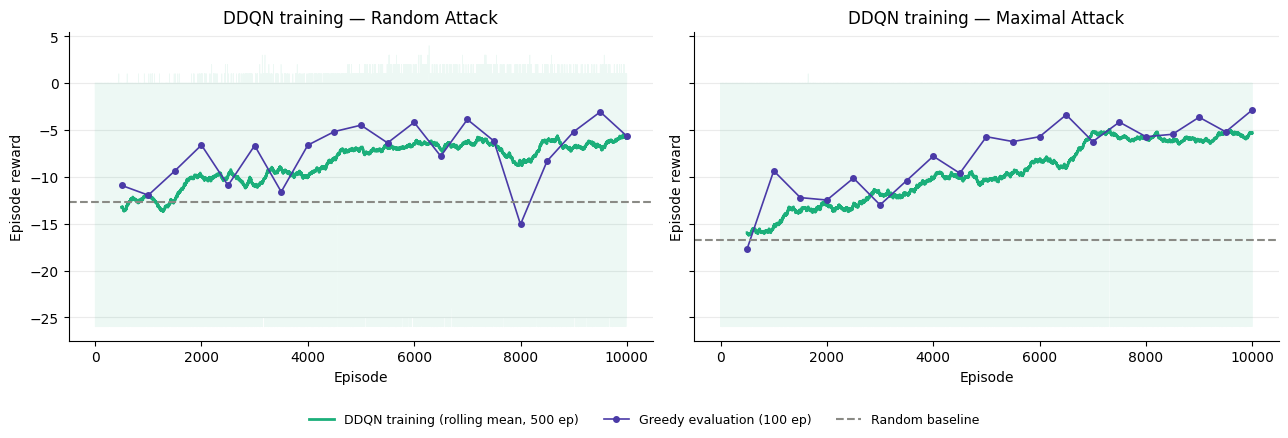

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)

for ax, rewards, evals, title, base in [
    (axes[0], ddqn_random_rewards, ddqn_random_evals, "Random Attack", results["random"]["Random baseline"]),
    (axes[1], ddqn_maximal_rewards, ddqn_maximal_evals, "Maximal Attack", results["maximal"]["Random baseline"]),
]:
    plot_learning_curve(ax, rewards, window=500, color=COLOR_DDQN, label="DDQN training (rolling mean, 500 ep)")
    ep_x, ep_y = zip(*evals)
    ax.plot(ep_x, ep_y, "o-", color="#4a3aa7", markersize=4, linewidth=1.2, label="Greedy evaluation (100 ep)")
    ax.axhline(base["avg_reward"], color=COLOR_BASELINE, linestyle="--", linewidth=1.5, label="Random baseline")
    ax.set_title(f"DDQN training — {title}")
    ax.legend_.remove()  # one shared legend below the figure instead of per-axes

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncols=3, frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

In [59]:
# Final greedy evaluation of the best checkpoints (shared 500-episode protocol)
set_seed(SEED)
results["random"]["DDQN"] = evaluate_policy(env_random, lambda o: ddqn_random.select_action(o, 0.0))
results["maximal"]["DDQN"] = evaluate_policy(env_maximal, lambda o: ddqn_maximal.select_action(o, 0.0))

print("Random Attack scenario")
print_stats("  Random baseline", results["random"]["Random baseline"])
print_stats("  SARSA          ", results["random"]["SARSA"])
print_stats("  DDQN           ", results["random"]["DDQN"])
print("\nMaximal Attack scenario")
print_stats("  Random baseline", results["maximal"]["Random baseline"])
print_stats("  DDQN           ", results["maximal"]["DDQN"])

Random Attack scenario
  Random baseline: positive reward 0.0% | breached 48.8% | detected 51.2% | avg reward -12.68 ± 12.99
  SARSA          : positive reward 25.2% | breached 20.6% | detected 79.4% | avg reward -5.06 ± 10.57
  DDQN           : positive reward 52.4% | breached 21.4% | detected 78.6% | avg reward -4.65 ± 10.69

Maximal Attack scenario
  Random baseline: positive reward 0.2% | breached 64.6% | detected 35.4% | avg reward -16.79 ± 12.43
  DDQN           : positive reward 0.0% | breached 17.2% | detected 82.8% | avg reward -4.47 ± 9.81


### DDQN results

*Random attack:* average reward **−4.65** (baseline −12.68), breaches down to **21.4%**, and a positive score in **52.4%** of episodes — twice SARSA's rate. Working on the full 20-dim state, the network discovered the data-hardening strategy on its own, and exploits it more systematically than the tabular agent.

*Maximal attack:* the harder opponent — the baseline is breached **64.6%** of the time — yet DDQN cuts breaches to **17.2%** (avg reward −4.47), mostly by maximizing detection (82.8%).

**Why does the defender never score a "win" against the maximal attacker?** It is not a training failure — it is the optimal trade-off. A positive reward requires spending the first ~4 moves hardening the data node, but against an attacker that always concentrates its strongest attack, those moves are unaffordable: a scripted "harden-then-detect" policy does reach ~21% positive episodes, but gets breached ~52% of the time (avg reward ≈ −13). The detection-focused policy DDQN converged to scores 0 on most episodes but keeps breaches at 17% — a much higher expected reward. The agent maximizes reward, not the win statistic; with this reward design, protecting the data beats accumulating points.

The evaluation curve (purple) also shows why best-checkpoint selection matters: the greedy policy oscillates between evaluations (e.g. the dip at episode 8000 on random attack), so taking the final weights would be a lottery.

## 5. Comparative Analysis

In [60]:
import pandas as pd


def results_table(scenario: str) -> pd.DataFrame:
    """Build a comparison table (one row per agent) for the given scenario."""
    df = pd.DataFrame(results[scenario]).T
    df["avg reward"] = df.apply(lambda r: f"{r['avg_reward']:.2f} ± {r['std_reward']:.2f}", axis=1)
    df = df[["win_pct", "hacked_pct", "detected_pct", "avg reward"]]
    df.columns = ["positive reward %", "breached %", "detected %", "avg reward"]
    return df


print("=== Random Attack scenario ===")
display(results_table("random"))
print("=== Maximal Attack scenario ===")
display(results_table("maximal"))

=== Random Attack scenario ===


,positive reward %,breached %,detected %,avg reward
Random baseline,0.0,48.8,51.2,-12.68 ± 12.99
SARSA,25.2,20.6,79.4,-5.06 ± 10.57
DDQN,52.4,21.4,78.6,-4.65 ± 10.69


=== Maximal Attack scenario ===


,positive reward %,breached %,detected %,avg reward
Random baseline,0.2,64.6,35.4,-16.79 ± 12.43
DDQN,0.0,17.2,82.8,-4.47 ± 9.81


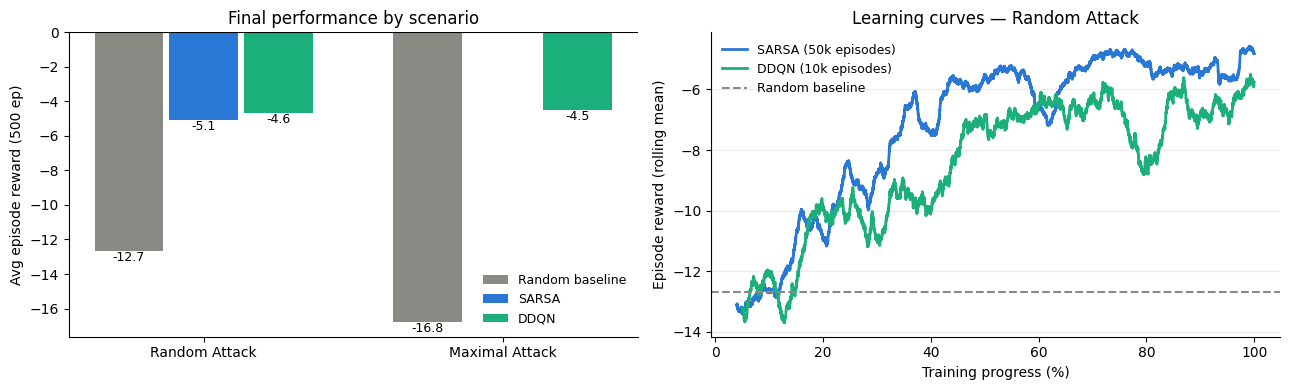

In [61]:
agent_colors = {"Random baseline": COLOR_BASELINE, "SARSA": COLOR_SARSA, "DDQN": COLOR_DDQN}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: average reward per agent and scenario
ax = axes[0]
scenarios = [("random", "Random Attack"), ("maximal", "Maximal Attack")]
agents = ["Random baseline", "SARSA", "DDQN"]
width = 0.25
for i, agent in enumerate(agents):
    xs, ys = [], []
    for j, (scenario, _) in enumerate(scenarios):
        if agent in results[scenario]:
            xs.append(j + (i - 1) * width)
            ys.append(results[scenario][agent]["avg_reward"])
    bars = ax.bar(xs, ys, width=width * 0.92, color=agent_colors[agent], label=agent)
    ax.bar_label(bars, fmt="%.1f", fontsize=9)
ax.set_xticks(range(len(scenarios)), [t for _, t in scenarios])
ax.set_ylabel("Avg episode reward (500 ep)")
ax.set_title("Final performance by scenario")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)

# Right: convergence comparison on the random-attack scenario.
# Different episode budgets (SARSA 50k vs DDQN 10k), so the x-axis is
# normalized to the fraction of the training budget.
ax = axes[1]
for rewards, window, color, label in [
    (sarsa_rewards, 2000, COLOR_SARSA, "SARSA (50k episodes)"),
    (ddqn_random_rewards, 500, COLOR_DDQN, "DDQN (10k episodes)"),
]:
    smoothed = rolling_mean(rewards, window)
    x = np.arange(window - 1, len(rewards)) / len(rewards) * 100
    ax.plot(x, smoothed, color=color, linewidth=2, label=label)
ax.axhline(results["random"]["Random baseline"]["avg_reward"], color=COLOR_BASELINE,
           linestyle="--", linewidth=1.5, label="Random baseline")
ax.set_xlabel("Training progress (%)")
ax.set_ylabel("Episode reward (rolling mean)")
ax.set_title("Learning curves — Random Attack")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## 6. Conclusions

**Findings:**
- Both agents dramatically outperform the random baseline. On the random-attack scenario SARSA reaches −5.1 and DDQN −4.7 average reward (baseline −12.7), cutting breaches from ~49% to ~21%. On the maximal-attack scenario DDQN cuts breaches from 64.6% to 17.2%.
- **SARSA vs DDQN:** the tabular agent needed domain-informed state aggregation to work at all, but once compact it converges smoothly and is competitive on average reward. DDQN needs no feature engineering, extracts more of the reward structure (52% vs 25% positive episodes), and transfers unchanged to the harder scenario — but its training is unstable and requires checkpoint selection. This is the classic trade-off: interpretability and stability vs generality.
- **Metric design matters:** "defender wins" measured by reward sign hides that every episode actually ends in breach or detection; against the maximal attacker the reward-optimal policy scores zero on purpose (see Section B discussion).

**Business framing.** For a healthcare provider, breach rate is the number that maps to regulatory exposure (patient-data confidentiality): the RL defender reduces simulated breaches by ~3–4× without hand-written rules, and adapts its resource allocation (hardening vs detection) to the attacker profile — precisely the adaptability and resource-optimization argument for RL-based defense.

**Limitations & future work.** gym-idsgame is a heavily abstracted model (small graph, integer attack/defense values, attacker bots with fixed strategies); results demonstrate methodology, not deployable defense.